In [77]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import joblib  # For saving and loading scalers
import matplotlib.pyplot as plt  # For plotting
import os
import warnings
warnings.filterwarnings("ignore")

In [80]:
# Function to calculate returns
def calculate_returns(prices, horizon=5):
    """
    Calculate returns over a given horizon.
    
    Args:
        prices (np.array): Array of stock prices.
        horizon (int): Horizon for calculating returns.
    
    Returns:
        np.array: Array of returns.
    """
    returns = (prices[horizon:] - prices[:-horizon]) / prices[:-horizon]
    return returns

# Function to create dataset
def create_dataset(data, lookback=30, horizon=5):
    X, y = [], []
    for i in range(lookback, len(data) - horizon):
        X.append(data[i - lookback:i, 0])
        y.append(data[i + horizon - 1, 0])  # Predict a single 5-day return
    return np.array(X), np.array(y)

# Function to build LSTM model
def build_lstm_model(lookback):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(lookback, 1)))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))  # Predict a single value (5-day return)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Load your stock data
stocks = pd.read_csv('Top_4_Stocks.csv')
stocks['Date'] = pd.to_datetime(stocks['Date'])
stocks.set_index('Date', inplace=True)

# Parameters
lookback = 30  # Number of past days to consider
horizon = 5    # Predict a single 5-day return
models_dict = {}

In [82]:
# Iterate over each stock (assuming each stock is in a separate column)
for stock_name in stocks.columns:
    prices = stocks[stock_name].values.reshape(-1, 1)

    # Calculate returns
    returns = calculate_returns(prices, horizon)
    returns = returns.reshape(-1, 1)

    # Align returns with dates
    returns_dates = stocks.index[horizon:]  # Slice dates to match returns

    training_dates = []
    testing_dates = []
    start_date = returns_dates[0]
    end_date = returns_dates[-1]

    # Generate training and testing date ranges
    while start_date + pd.DateOffset(years=4) <= end_date:
        training_dates.append((start_date, start_date + pd.DateOffset(years=3)))
        testing_dates.append((start_date + pd.DateOffset(years=3), start_date + pd.DateOffset(years=4)))
        start_date += pd.DateOffset(years=1)

    # Train and test for each date range
    for train_date, test_date in zip(training_dates, testing_dates):
        # Split data into training and testing sets
        train_data = returns[(returns_dates >= train_date[0]) & (returns_dates <= train_date[1])]
        test_data = returns[(returns_dates >= test_date[0]) & (returns_dates <= test_date[1])]

        # Scale the training data and use the same scaler for the test data
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_train_data = scaler.fit_transform(train_data)
        scaled_test_data = scaler.transform(test_data)

        # Create datasets
        X_train, y_train = create_dataset(scaled_train_data, lookback, horizon)
        X_test, y_test = create_dataset(scaled_test_data, lookback, horizon)

        # Reshape data for LSTM
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

        # Build and train the model
        model = build_lstm_model(lookback)
        model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test), verbose=0)

        # Save the model and scaler with a meaningful name
        model_name = f"{stock_name}_{train_date[0].strftime('%Y%m%d')}_{test_date[0].strftime('%Y%m%d')}"
        model.save(f"models/{model_name}.h5")
        joblib.dump(scaler, f"models/{model_name}_scaler.pkl")  # Save the scaler
        models_dict[model_name] = (model, scaler)

        print(f"Model and scaler saved: {model_name}")


Model and scaler saved: HDFCBANK.NS_20150108_20180108
Model and scaler saved: HDFCBANK.NS_20160108_20190108
Model and scaler saved: HDFCBANK.NS_20170108_20200108
Model and scaler saved: HDFCBANK.NS_20180108_20210108
Model and scaler saved: HDFCBANK.NS_20190108_20220108
Model and scaler saved: HDFCBANK.NS_20200108_20230108
Model and scaler saved: HDFCBANK.NS_20210108_20240108
Model and scaler saved: INFY.NS_20150108_20180108
Model and scaler saved: INFY.NS_20160108_20190108
Model and scaler saved: INFY.NS_20170108_20200108
Model and scaler saved: INFY.NS_20180108_20210108
Model and scaler saved: INFY.NS_20190108_20220108
Model and scaler saved: INFY.NS_20200108_20230108
Model and scaler saved: INFY.NS_20210108_20240108
Model and scaler saved: RELIANCE.NS_20150108_20180108
Model and scaler saved: RELIANCE.NS_20160108_20190108
Model and scaler saved: RELIANCE.NS_20170108_20200108
Model and scaler saved: RELIANCE.NS_20180108_20210108
Model and scaler saved: RELIANCE.NS_20190108_20220108
Mo

In [ ]:
# Function to evaluate model and return predictions
def evaluate_and_return_predictions(model_name, test_data, test_dates, lookback, horizon):
    """
    Evaluate the model on the test data and return predictions.
    
    Args:
        model_name (str): Name of the saved model (e.g., 'StockA_20150101_20180101').
        test_data (np.array): Test data for evaluation.
        test_dates (pd.DatetimeIndex): Dates corresponding to the test data.
        lookback (int): Number of past days to consider.
        horizon (int): Horizon for prediction (5 for fifth day).
    
    Returns:
        np.array: Predicted returns.
        np.array: Actual returns.
        np.array: Dates corresponding to the predictions.
    """
    # Load the model
    model = load_model(f"models/{model_name}.h5")

    # Load the scaler
    scaler = joblib.load(f"models/{model_name}_scaler.pkl")

    # Prepare the test data
    scaled_test_data = scaler.transform(test_data)
    X_test, y_test = create_dataset(scaled_test_data, lookback, horizon)

    # Reshape data for LSTM
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    # Make predictions
    scaled_predictions = model.predict(X_test)

    # find MAE and RMSE
    mae = np.mean(np.abs(scaled_predictions - y_test))
    rmse = np.sqrt(mean_squared_error(y_test, scaled_predictions))

    predictions = scaler.inverse_transform(scaled_predictions)  # Reverse scaling for predictions

    # Reshape y_test to 2D before inverse transform
    y_test = y_test.reshape(-1, 1)  # Reshape to (n_samples, 1)
    actual = scaler.inverse_transform(y_test)   # Reverse scaling for actual values

    # Get dates for the predictions
    prediction_dates = test_dates[lookback + horizon - 1:lookback + horizon - 1 + len(actual)]

    return predictions.flatten(), actual.flatten(), prediction_dates, mae, rmse

# Function to plot true vs predicted returns
def plot_true_vs_predicted(true_returns, predicted_returns, dates, model_name):
    """
    Plot true vs predicted returns.
    
    Args:
        true_returns (list): List of true returns.
        predicted_returns (list): List of predicted returns.
        dates (list): List of dates corresponding to the returns.
        model_name (str): Name of the model.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(dates, true_returns, label='True Returns')
    plt.plot(dates, predicted_returns, label='Predicted Returns')
    plt.title(f"True vs Predicted Returns for {model_name}")
    plt.xlabel('Date')
    plt.ylabel('Returns')
    plt.legend()
    plt.grid()
    plt.show()


def get_returns(stock_name):
    true_returns = []
    predicted_returns = []
    rmse_arr = []
    mae_arr = []
    all_dates = []

    for i in range(len(training_dates)):
        train_start, train_end = training_dates[i][0].strftime('%Y%m%d'), training_dates[i][1].strftime('%Y%m%d')
        test_start, test_end = testing_dates[i][0].strftime('%Y%m%d'), testing_dates[i][1].strftime('%Y%m%d')
        model_name = f"{stock_name}_{train_start}_{test_start}"

        test_data = returns[(returns_dates >= pd.to_datetime(test_start)) & (returns_dates <= pd.to_datetime(test_end))]
        test_dates = returns_dates[(returns_dates >= pd.to_datetime(test_start)) & (returns_dates <= pd.to_datetime(test_end))]

        # Evaluate and get predictions
        predictions, actual, prediction_dates, mae, rmse = evaluate_and_return_predictions(model_name, test_data, test_dates, lookback, horizon)

        # Append results
        true_returns.extend(actual.flatten())
        predicted_returns.extend(predictions.flatten())
        all_dates.extend(prediction_dates)
        rmse_arr.append(rmse)
        mae_arr.append(mae)
    
    return true_returns, predicted_returns, all_dates, rmse_arr, mae_arr

# Plot true vs predicted returns

Stock: HDFCBANK.NS
7/7 [==============================] - 1s 10ms/step


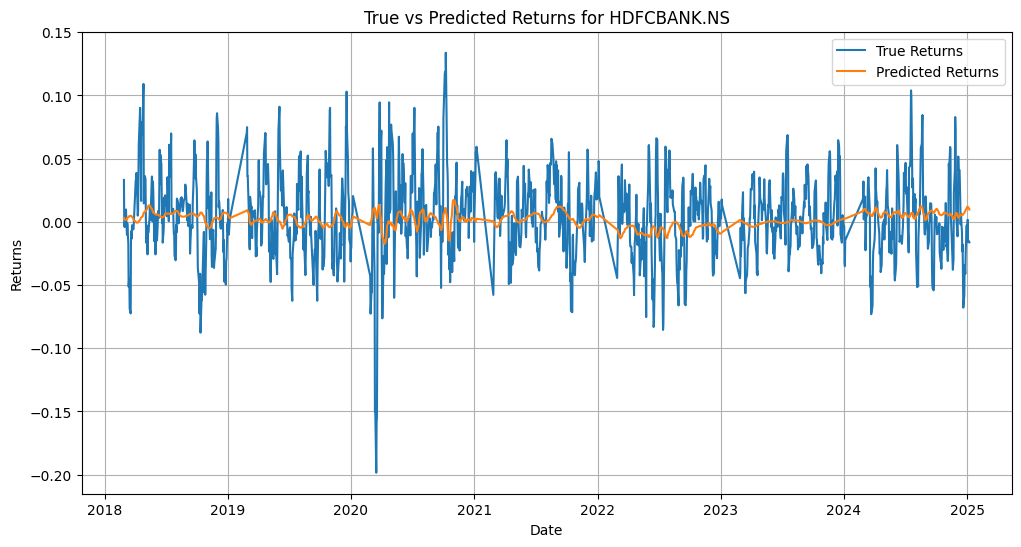

Mean RMSE: 0.13872589243112526
Mean MAE: 0.10548104215216683


Stock: INFY.NS
7/7 [==============================] - 1s 13ms/step


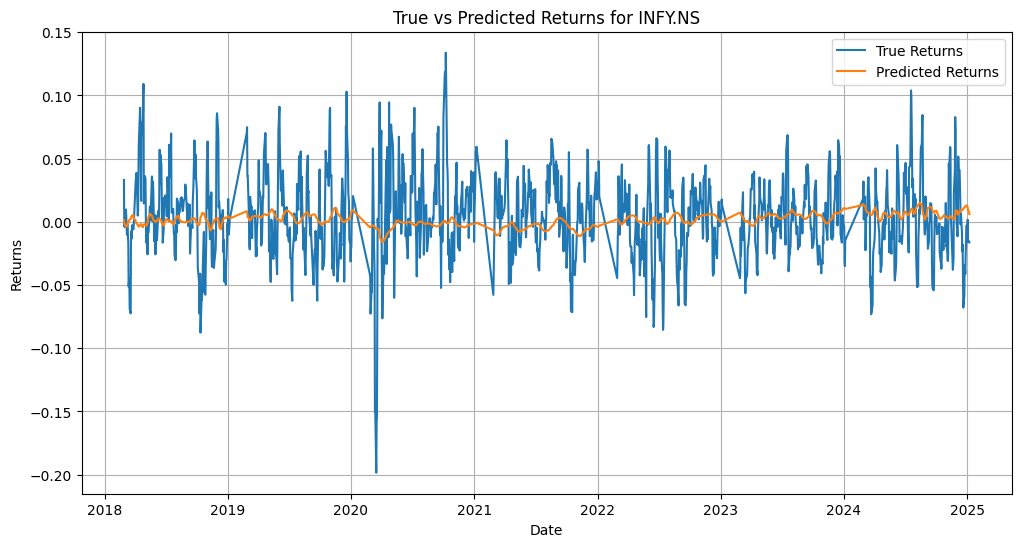

Mean RMSE: 0.1127362567384947
Mean MAE: 0.08624689172440672


Stock: RELIANCE.NS
7/7 [==============================] - 1s 11ms/step


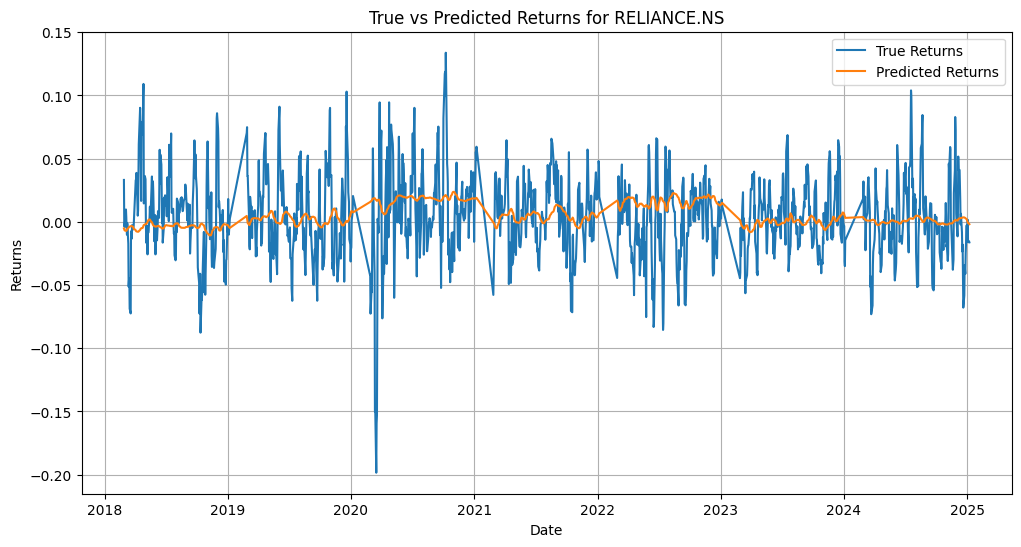

Mean RMSE: 0.10449281363062769
Mean MAE: 0.07942967508507197


Stock: TCS.NS
7/7 [==============================] - 1s 13ms/step


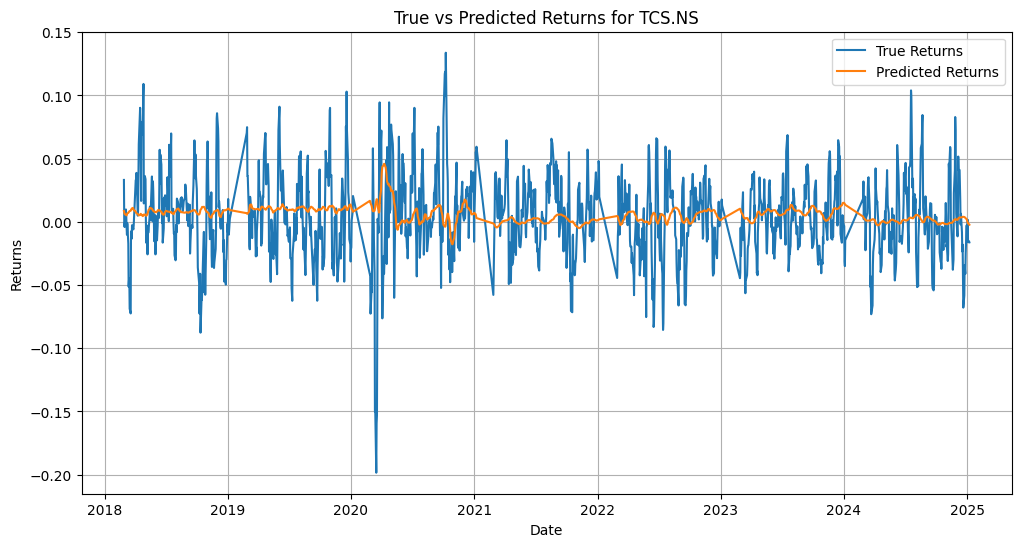

Mean RMSE: 0.13752381817959966
Mean MAE: 0.10497822678568612




In [84]:
for stock_name in stocks.columns:
    print(f"Stock: {stock_name}")
    true_returns, predicted_returns, all_dates, rmse_arr, mae_arr = get_returns(stock_name)
    plot_true_vs_predicted(true_returns, predicted_returns, all_dates, stock_name)
    print(f"Mean RMSE: {np.mean(rmse_arr)}")
    print(f"Mean MAE: {np.mean(mae_arr)}")
    print("\n")
